
# 基于U-Net模型进行城市遥感图像分割实验

## 1. U-Net模型介绍

### U-Net是什么？
U-Net是一个强大的全卷积网络(FCN-based)架构，专门为医学图像分割而设计，后来被广泛应用于各种分割任务。

### 核心特点：
1. **编码-解码结构**：左侧编码器(下采样)逐步提取特征，右侧解码器(上采样)恢复空间信息
2. **跳连接**：编码器对应层的特征直接连接到解码器，保留细节信息
3. **高效学习**：从少量训练数据中学习强大的分割特征
4. **多尺度特征**：通过不同层级的特征融合实现精准分割
### 应用优势：
- 准确定位图像边界
- 高效的参数量
- 对不规则形状的自适应能力强
- 广泛应用于医学、遥感等领域

## 2. 数据集介绍

### Mumbai高分辨率卫星图像数据集
**数据集概述**：
- **来源**：Pleiades-1A卫星（0.5米分辨率）于2017年3月15日获取
- **覆盖区域**：印度孟买市
- **原始图像**：110张 600×600 像素的高分辨率卫星图像
- **手工标注**：使用Intel CVAT工具进行8910个120×120像素图块标注

### 语义类别（7类）：
| 类别 | RGB值 | 说明 |
|------|-------|------|
| Built-up | (200, 200, 200) | 建筑物区域 |
| Vegetation | (80, 140, 50) | 绿色植被覆盖 |
| Barren | (200, 160, 40) | 裸露土地 |
| Water | (40, 120, 240) | 水体 |
| Impervious Surfaces | (100, 100, 150) | 不透水表面（道路、停车场等） |
| Informal Settlements | (250, 235, 185) | 非正式居民区（贫民区） |
| Unlabelled | (0, 0, 0) | 未标记区域 |

### 数据划分：
- **训练集**：80% (7128个图块)
- **验证集**：10% (891个图块)
- **测试集**：10% (891个图块)

### 数据集获取链接：
**Mendeley Data**: https://data.mendeley.com/datasets/xj2v49zt26


## 3. 导入必要的库

In [18]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pickle
from pathlib import Path
%matplotlib inline

# PyTorch深度学习框架
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# 评估指标
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# 检查GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch版本: {torch.__version__}")
print(f"使用设备: {device}")
print(f"GPU可用: {torch.cuda.is_available()}")

PyTorch版本: 2.10.0+cpu
使用设备: cpu
GPU可用: False


## 4. 数据集配置与加载

### 4.1 数据集下载（在线）
数据集在 Mendeley Data，需要网页同意条款后下载。
下载后把压缩包放到项目的 `Dataset/` 目录并解压，形成以下结构：

- Dataset/Main_Dataset/...
- Dataset/Prepared_Dataset/train/images
- Dataset/Prepared_Dataset/train/masks
- Dataset/Prepared_Dataset/val/images
- Dataset/Prepared_Dataset/val/masks
- Dataset/Prepared_Dataset/test/images
- Dataset/Prepared_Dataset/test/masks

下载地址：
https://data.mendeley.com/datasets/xj2v49zt26/1

In [19]:
from pathlib import Path
import zipfile
import webbrowser

# 打开下载页面（需要手动确认并下载）
webbrowser.open("https://data.mendeley.com/datasets/xj2v49zt26/1")

# 把下载的压缩包放到 Dataset/ 目录，然后运行解压
dataset_root = Path("../Dataset").resolve()
dataset_root.mkdir(parents=True, exist_ok=True)

zip_path = dataset_root / "mumbai_dataset.zip"
if zip_path.exists():
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(dataset_root)
    print(f"解压完成: {dataset_root}")
else:
    print(f"未找到压缩包: {zip_path}")
    print("请把下载的 zip 文件改名为 mumbai_dataset.zip 并放到 Dataset/ 目录")

未找到压缩包: D:\anlixinagmu\Mumbai-Semantic-Segmentation-Dataset-main\Dataset\mumbai_dataset.zip
请把下载的 zip 文件改名为 mumbai_dataset.zip 并放到 Dataset/ 目录


In [20]:
# 数据路径配置
data_dir = "../Dataset/Dataset/Prepared_Dataset"
train_images_dir = os.path.join(data_dir, "train", "images")
train_masks_dir = os.path.join(data_dir, "train", "masks")
val_images_dir = os.path.join(data_dir, "val", "images")
val_masks_dir = os.path.join(data_dir, "val", "masks")
test_images_dir = os.path.join(data_dir, "test", "images")
test_masks_dir = os.path.join(data_dir, "test", "masks")

# 创建输出目录
os.makedirs('./Output', exist_ok=True)

# 检查数据集
print('数据集统计：')
print(f'训练集图像数: {len(os.listdir(train_images_dir))}')
print(f'训练集掩码数: {len(os.listdir(train_masks_dir))}')
print(f'验证集图像数: {len(os.listdir(val_images_dir))}')
print(f'验证集掩码数: {len(os.listdir(val_masks_dir))}')
print(f'测试集图像数: {len(os.listdir(test_images_dir))}')
print(f'测试集掩码数: {len(os.listdir(test_masks_dir))}')

数据集统计：
训练集图像数: 7128
训练集掩码数: 7128
验证集图像数: 891
验证集掩码数: 891
测试集图像数: 891
测试集掩码数: 891


## 5. 标签编码和解码函数

In [21]:
# 定义类别和颜色
label_names = ['Built-up', 'Vegetation', 'Barren', 'Water', 'Impervious Surfaces', 'Informal Settlements', 'Unlabelled']
label_codes = [(200, 200, 200), (80, 140, 50), (200, 160, 40), (40, 120, 240), 
               (100, 100, 150), (250, 235, 185), (0, 0, 0)]

# 创建RGB到类别ID的映射
code2id = {v: k for k, v in enumerate(label_codes)}
id2code = {k: v for k, v in enumerate(label_codes)}
name2id = {v: k for k, v in enumerate(label_names)}
id2name = {k: v for k, v in enumerate(label_names)}

print(f"类别映射: {id2name}")

def rgb_to_mask(rgb_image, colormap=id2code):
    """将RGB掩码转换为类别ID掩码（用于PyTorch）"""
    mask = np.zeros((rgb_image.shape[0], rgb_image.shape[1]), dtype=np.int64)
    for i, color in enumerate(colormap.keys()):
        mask[(rgb_image == colormap[i]).all(axis=2)] = i
    return mask

def mask_to_rgb(mask, colormap=id2code):
    """将类别ID掩码转换回RGB掩码"""
    output = np.zeros(mask.shape + (3,), dtype=np.uint8)
    for k in colormap.keys():
        output[mask==k] = colormap[k]
    return output

类别映射: {0: 'Built-up', 1: 'Vegetation', 2: 'Barren', 3: 'Water', 4: 'Impervious Surfaces', 5: 'Informal Settlements', 6: 'Unlabelled'}


## 6. 自定义PyTorch数据集类

In [28]:
# 课堂快速模式：只用部分数据+更少轮数
quick_mode = True
subset_fraction = 0.1  # 课堂演示用 10%
full_num_epochs = 10
quick_num_epochs = 10

class SegmentationDataset(Dataset):
    """Mumbai卫星图像分割数据集"""
    def __init__(self, images_dir, masks_dir, transform=None, target_size=(128, 128)):
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.transform = transform
        self.target_size = target_size
        
        # 获取所有图像文件
        self.image_files = sorted([f for f in os.listdir(images_dir) if f.endswith(('.tif', '.png', '.jpg'))])
        
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        # 读取图像
        img_name = self.image_files[idx]
        img_path = self.images_dir / img_name
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, self.target_size)
        
        # 读取掩码
        mask_name = img_name.replace('.tif', '.png').replace('.jpg', '.png')
        mask_path = self.masks_dir / mask_name
        mask = cv2.imread(str(mask_path))
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)
        
        # 转换为类别ID
        mask = rgb_to_mask(mask, id2code)
        
        # 归一化图像
        image = image.astype(np.float32) / 255.0
        
        # 转换为张量
        image = torch.from_numpy(image).permute(2, 0, 1)  # (H, W, C) -> (C, H, W)
        mask = torch.from_numpy(mask).long()
        
        return image, mask

# 创建数据集
train_dataset = SegmentationDataset(train_images_dir, train_masks_dir, target_size=(128, 128))
val_dataset = SegmentationDataset(val_images_dir, val_masks_dir, target_size=(128, 128))
test_dataset = SegmentationDataset(test_images_dir, test_masks_dir, target_size=(128, 128))

# 课堂快速模式：抽取子集
if quick_mode:
    def _subset(ds, fraction, seed=42):
        total = len(ds)
        n = max(1, int(total * fraction))
        g = torch.Generator().manual_seed(seed)
        idx = torch.randperm(total, generator=g)[:n]
        return torch.utils.data.Subset(ds, idx)
    train_dataset = _subset(train_dataset, subset_fraction)
    val_dataset = _subset(val_dataset, subset_fraction)
    test_dataset = _subset(test_dataset, subset_fraction)
    print(f"快速模式启用：使用 {subset_fraction*100:.0f}% 数据")
else:
    print("完整模式启用：使用全部数据")

print(f"训练集大小: {len(train_dataset)}")
print(f"验证集大小: {len(val_dataset)}")
print(f"测试集大小: {len(test_dataset)}")

快速模式启用：使用 10% 数据
训练集大小: 712
验证集大小: 89
测试集大小: 89


## 7. 创建数据加载器

In [29]:
batch_size = 8
num_workers = 0  # Windows avoids multiprocessing issues
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory
 )
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory
 )
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory
 )

print(f"train batches: {len(train_loader)}")
print(f"val batches: {len(val_loader)}")
print(f"test batches: {len(test_loader)}")

train batches: 89
val batches: 12
test batches: 12


## 8. U-Net模型定义

In [30]:
class UNet(nn.Module):
    """U-Net分割模型 (PyTorch实现)"""
    def __init__(self, in_channels=3, num_classes=7):
        super(UNet, self).__init__()
        
        # 定义卷积块
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            )
        
        # 编码器（下采样）
        self.enc1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.enc3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        self.enc4 = conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(2, 2)
        
        # 瓶颈层
        self.bottleneck = conv_block(512, 1024)
        
        # 解码器（上采样）
        self.upconv4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = conv_block(1024, 512)  # 1024 = 512 + 512 (skip connection)
        
        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)  # 512 = 256 + 256
        
        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)  # 256 = 128 + 128
        
        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)  # 128 = 64 + 64
        
        # 输出层
        self.final = nn.Conv2d(64, num_classes, 1)
    
    def forward(self, x):
        # 编码器
        enc1 = self.enc1(x)
        x = self.pool1(enc1)
        
        enc2 = self.enc2(x)
        x = self.pool2(enc2)
        
        enc3 = self.enc3(x)
        x = self.pool3(enc3)
        
        enc4 = self.enc4(x)
        x = self.pool4(enc4)
        
        # 瓶颈
        x = self.bottleneck(x)
        
        # 解码器（带跳连接）
        x = self.upconv4(x)
        x = torch.cat([x, enc4], dim=1)  # 跳连接
        x = self.dec4(x)
        
        x = self.upconv3(x)
        x = torch.cat([x, enc3], dim=1)
        x = self.dec3(x)
        
        x = self.upconv2(x)
        x = torch.cat([x, enc2], dim=1)
        x = self.dec2(x)
        
        x = self.upconv1(x)
        x = torch.cat([x, enc1], dim=1)
        x = self.dec1(x)
        
        # 输出
        x = self.final(x)
        return x

# 创建模型
model = UNet(in_channels=3, num_classes=7).to(device)
print(model)

# 统计参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\\n总参数数: {total_params:,}")
print(f"可训练参数数: {trainable_params:,}")

UNet(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False

## 9. 损失函数和优化器

In [31]:
# 定义损失函数
criterion = nn.CrossEntropyLoss()

# 定义优化器
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 定义学习率调度器
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print('损失函数和优化器已配置')

损失函数和优化器已配置


## 10. 训练和验证函数

In [32]:
def dice_score(outputs, targets, smooth=1.0):
    """计算Dice系数"""
    num_classes = outputs.shape[1]
    dice = 0.0
    
    for i in range(num_classes):
        pred = (outputs.argmax(1) == i).float()
        target = (targets == i).float()
        
        intersection = (pred * target).sum()
        union = pred.sum() + target.sum()
        
        if union > 0:
            dice += (2 * intersection + smooth) / (union + smooth)
    
    return dice / num_classes

def train_epoch(model, train_loader, criterion, optimizer, device):
    """训练一个epoch"""
    model.train()
    train_loss = 0.0
    train_dice = 0.0
    
    pbar = tqdm(train_loader, desc='Training')
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        # 前向传播
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        # 反向传播
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_dice += dice_score(outputs, masks).item()
        
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
    
    avg_loss = train_loss / len(train_loader)
    avg_dice = train_dice / len(train_loader)
    return avg_loss, avg_dice

def validate(model, val_loader, criterion, device):
    """验证模型"""
    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc='Validating')
        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            val_loss += loss.item()
            val_dice += dice_score(outputs, masks).item()
            
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})
    
    avg_loss = val_loss / len(val_loader)
    avg_dice = val_dice / len(val_loader)
    return avg_loss, avg_dice

print('训练函数已定义')

训练函数已定义


## 11. 模型训练
课堂快速模式：`quick_mode=True` 会用 10% 数据 + 10 轮。
完整实验：把 `quick_mode=False`，并可把 `subset_fraction=1.0`，训练轮数自动恢复到 10。

In [33]:
# 训练参数
num_epochs = quick_num_epochs if quick_mode else full_num_epochs
best_val_loss = float('inf')
patience = 3
patience_counter = 0

# 记录训练历史
history = {
    'train_loss': [],
    'val_loss': [],
    'train_dice': [],
    'val_dice': []
}

print(f"开始训练模型，共{num_epochs}轮...\n")

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 50)
    
    # 训练
    train_loss, train_dice = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # 验证
    val_loss, val_dice = validate(model, val_loader, criterion, device)
    
    # 记录
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_dice'].append(train_dice)
    history['val_dice'].append(val_dice)
    
    print(f"训练中 - 损失: {train_loss:.4f}, Dice: {train_dice:.4f}")
    print(f"验证中 - 损失: {val_loss:.4f}, Dice: {val_dice:.4f}")
    
    # 学习率调度
    scheduler.step(val_loss)
    
    # 保存最佳模型
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), './Output/unet_best.pt')
        print("✓ 最佳模型已保存")
    else:
        patience_counter += 1
        print(f"未改进 ({patience_counter}/{patience})")
        
        if patience_counter >= patience:
            print("\n早停触发，训练停止")
            break

print(f"\n{'='*50}")
print("训练完成！")
print(f"最佳验证损失: {best_val_loss:.4f}")

开始训练模型，共10轮...


Epoch 1/10
--------------------------------------------------


Validating: 100%|██████████| 12/12 [00:11<00:00,  1.02it/s, loss=0.8987]


训练中 - 损失: 1.3112, Dice: 0.3881
验证中 - 损失: 1.2141, Dice: 0.3646
✓ 最佳模型已保存

Epoch 2/10
--------------------------------------------------


Validating: 100%|██████████| 12/12 [00:10<00:00,  1.18it/s, loss=0.7584]


训练中 - 损失: 1.0520, Dice: 0.4486
验证中 - 损失: 0.8358, Dice: 0.4500
✓ 最佳模型已保存

Epoch 3/10
--------------------------------------------------


...

训练中 - 损失: 0.7934, Dice: 0.5343
验证中 - 损失: 0.5370, Dice: 0.5938
✓ 最佳模型已保存

Epoch 9/10
--------------------------------------------------


Validating: 100%|██████████| 12/12 [00:09<00:00,  1.20it/s, loss=0.5029]


训练中 - 损失: 0.7106, Dice: 0.5776
验证中 - 损失: 0.5115, Dice: 0.5850
✓ 最佳模型已保存

Epoch 10/10
--------------------------------------------------


Validating: 100%|██████████| 12/12 [00:10<00:00,  1.19it/s, loss=0.5749]

训练中 - 损失: 0.7314, Dice: 0.5526
验证中 - 损失: 0.5129, Dice: 0.5957
未改进 (1/3)

训练完成！
最佳验证损失: 0.5115


## 12. 训练历史可视化（Loss曲线）

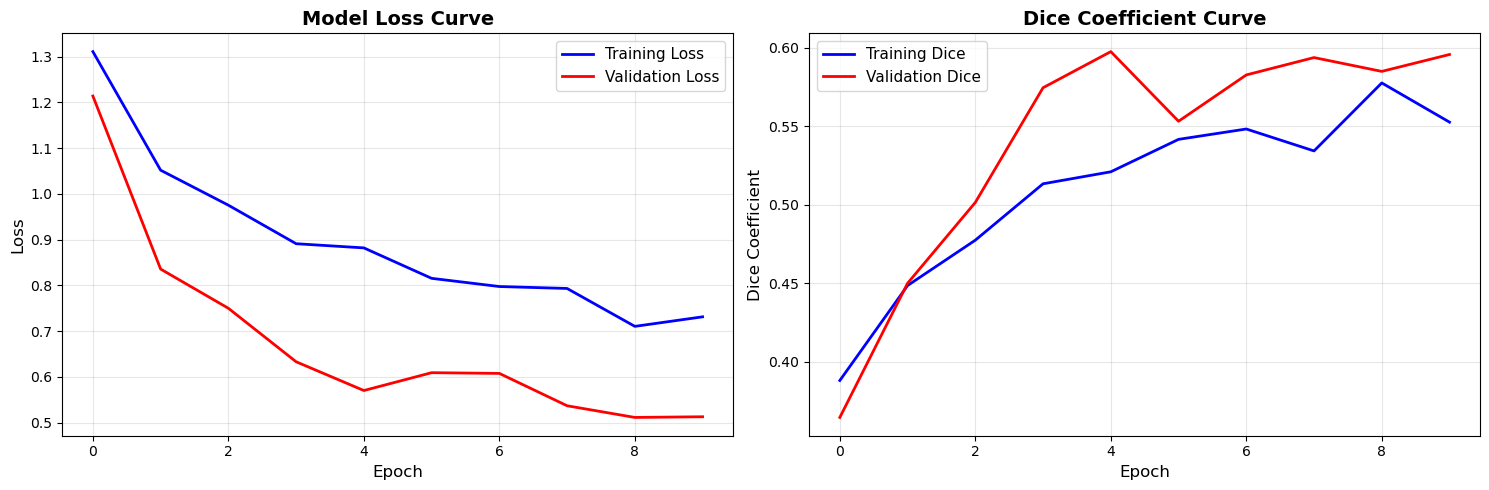

最终训练损失: 0.7314
最终验证损失: 0.5129
最终Dice系数: 0.5526


In [34]:
# 保存训练历史
with open('./Output/unet_history.pkl', 'wb') as f:
    pickle.dump(history, f)

# 绘制Loss曲线
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 损失曲线
axes[0].plot(history['train_loss'], 'b-', linewidth=2, label='Training Loss')
axes[0].plot(history['val_loss'], 'r-', linewidth=2, label='Validation Loss')
axes[0].set_title('Model Loss Curve', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Dice系数曲线
axes[1].plot(history['train_dice'], 'b-', linewidth=2, label='Training Dice')
axes[1].plot(history['val_dice'], 'r-', linewidth=2, label='Validation Dice')
axes[1].set_title('Dice Coefficient Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Dice Coefficient', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./Output/unet_loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'最终训练损失: {history["train_loss"][-1]:.4f}')
print(f'最终验证损失: {history["val_loss"][-1]:.4f}')
print(f'最终Dice系数: {history["train_dice"][-1]:.4f}')

## 13. 模型评估

In [35]:
# 加载最佳模型
model.load_state_dict(torch.load('./Output/unet_best.pt', map_location=device))
model.eval()

# 测试模型
test_loss = 0.0
test_dice = 0.0

print('\\n模型评估中...')
with torch.no_grad():
    pbar = tqdm(test_loader, desc='Testing')
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        test_loss += loss.item()
        test_dice += dice_score(outputs, masks).item()

test_loss /= len(test_loader)
test_dice /= len(test_loader)

print(f'\\n测试集评估结果：')
print(f'测试损失: {test_loss:.4f}')
print(f'Dice系数: {test_dice:.4f}')

\n模型评估中...


Testing: 100%|██████████| 12/12 [00:10<00:00,  1.19it/s]

\n测试集评估结果：
测试损失: 0.3776
Dice系数: 0.6147


## 14. 可视化分割结果

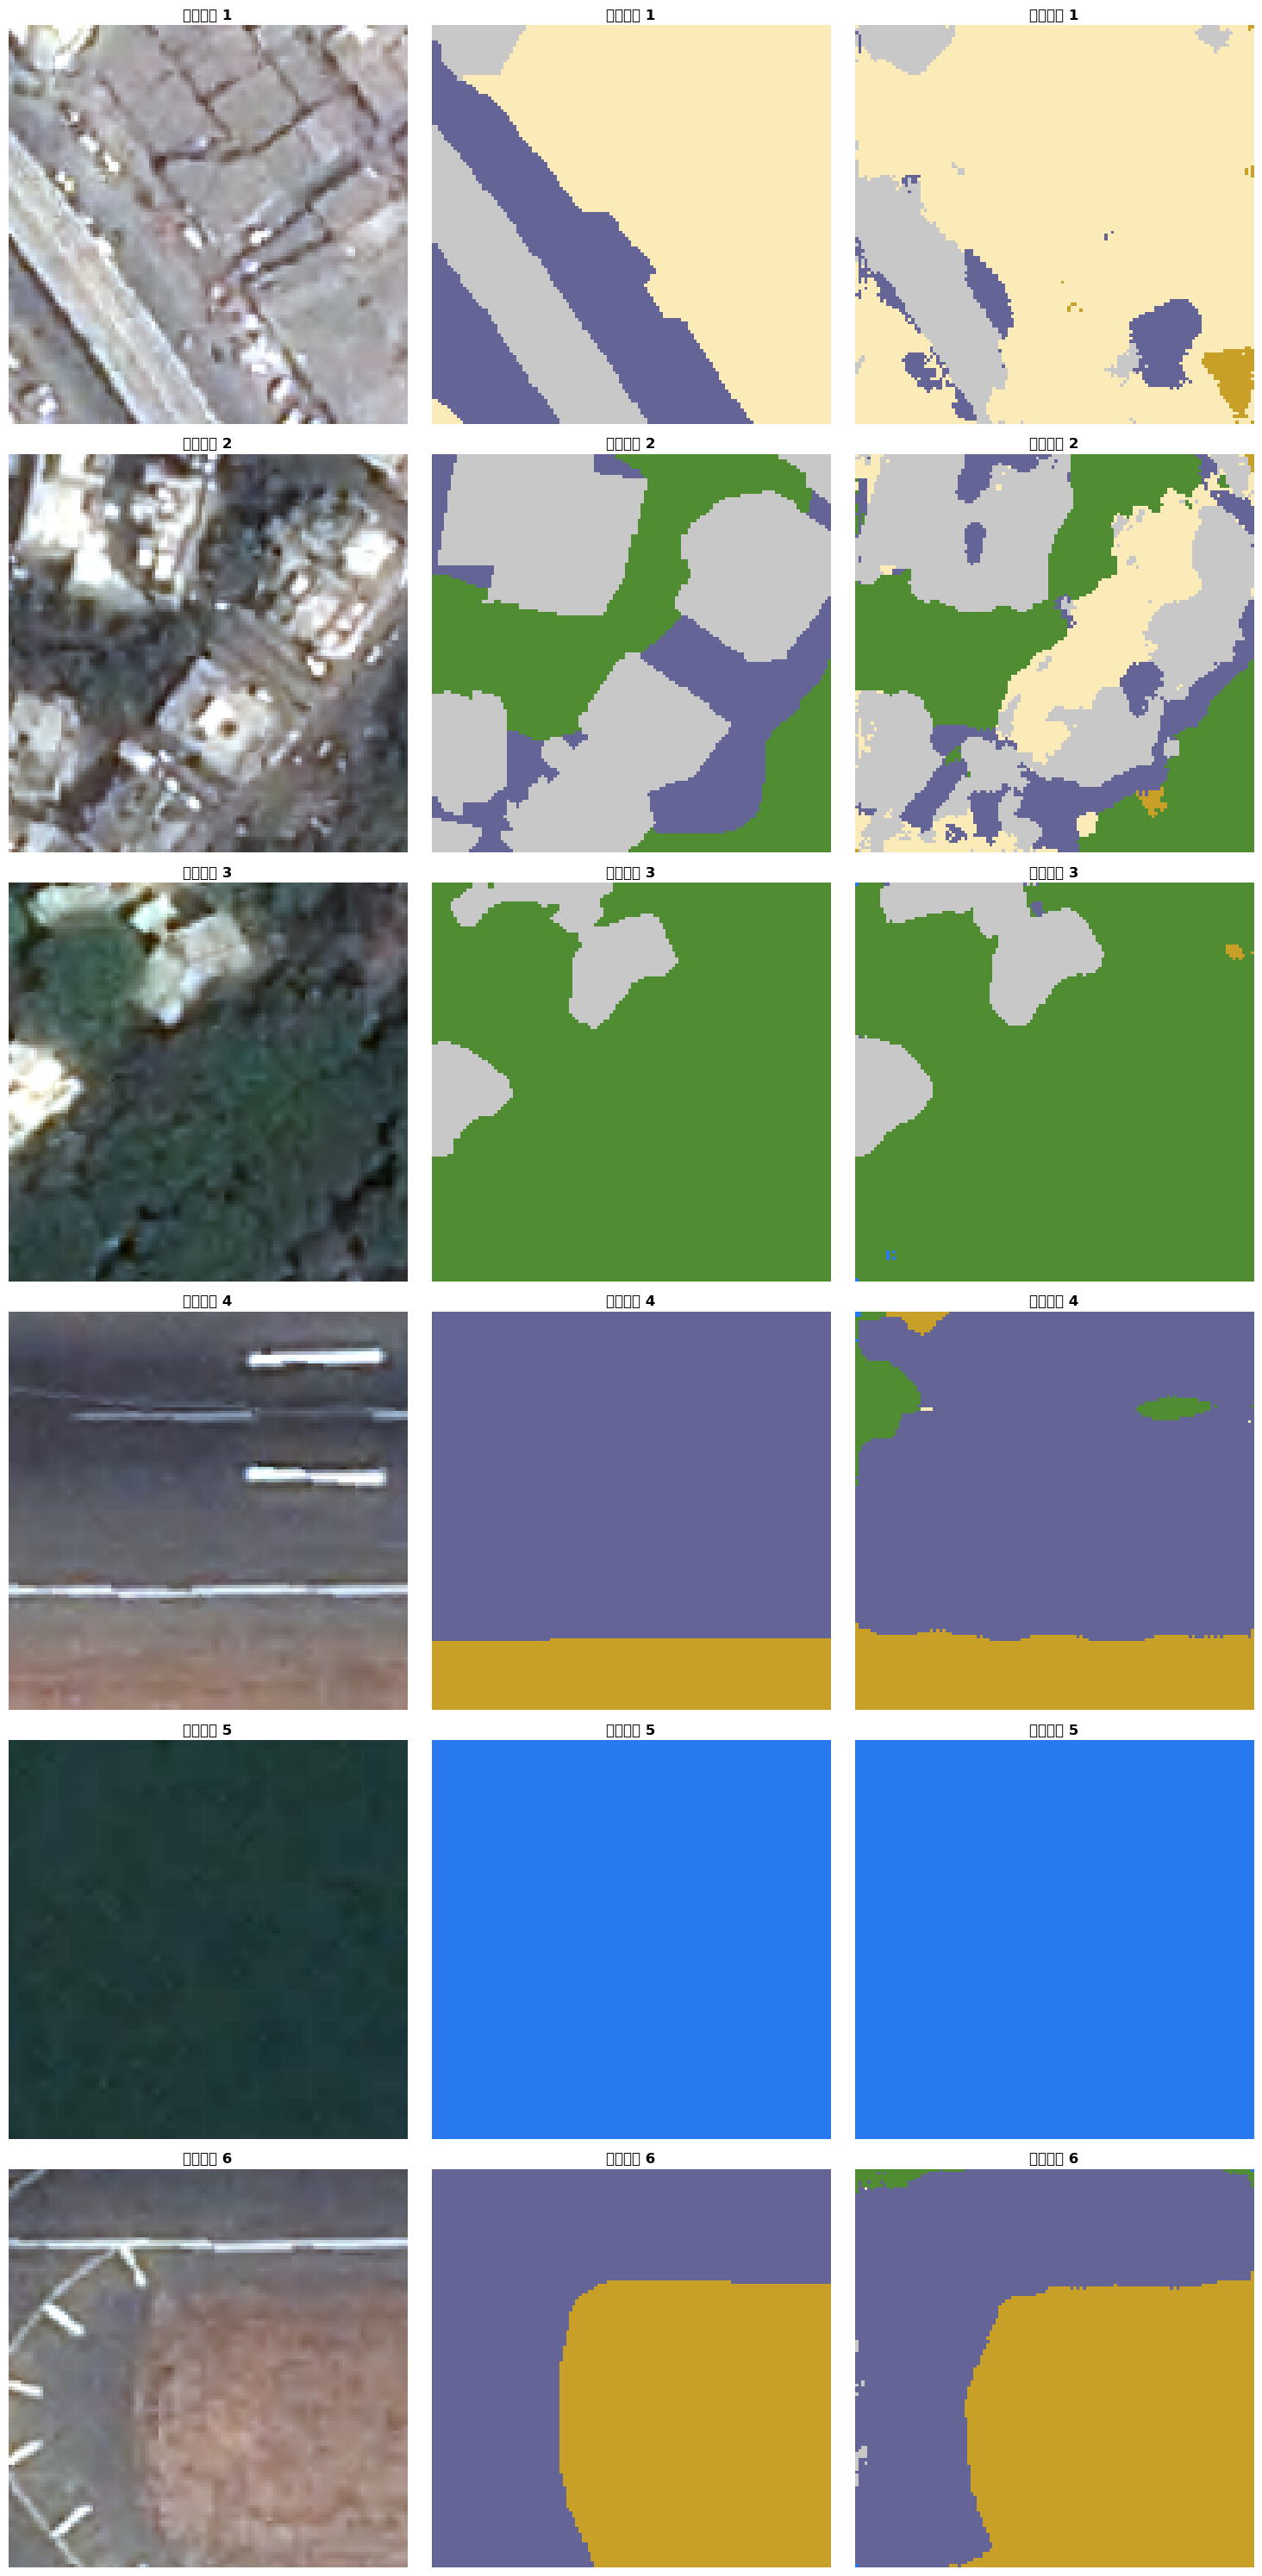

分割结果已保存


In [36]:
# 展示分割结果
num_samples = 6
fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))

model.eval()
with torch.no_grad():
    for i, (images, masks) in enumerate(test_loader):
        if i >= 1:  # 只取一个batch的6张图
            break
        
        images = images.to(device)
        outputs = model(images)
        
        # 获取预测
        preds = outputs.argmax(1).cpu().numpy()
        imgs = images.cpu().numpy()
        msks = masks.numpy()
        
        for j in range(min(num_samples, len(images))):
            # 原始图像 (C, H, W) -> (H, W, C)
            img = np.transpose(imgs[j], (1, 2, 0))
            
            # 真实掩码
            true_mask = mask_to_rgb(msks[j], id2code)
            
            # 预测掩码
            pred_mask = mask_to_rgb(preds[j], id2code)
            
            # 显示原始图像
            axes[j, 0].imshow(img)
            axes[j, 0].set_title(f'原始图像 {j+1}', fontsize=12, fontweight='bold')
            axes[j, 0].axis('off')
            
            # 显示真实掩码
            axes[j, 1].imshow(true_mask)
            axes[j, 1].set_title(f'真实掩码 {j+1}', fontsize=12, fontweight='bold')
            axes[j, 1].axis('off')
            
            # 显示预测掩码
            axes[j, 2].imshow(pred_mask)
            axes[j, 2].set_title(f'预测掩码 {j+1}', fontsize=12, fontweight='bold')
            axes[j, 2].axis('off')

plt.tight_layout()
plt.savefig('./Output/unet_segmentation_results.png', dpi=300, bbox_inches='tight')
plt.show()

print('分割结果已保存')

## 15. 详细的分割质量评估

In [38]:
print('\\n分类报告：')
print(classification_report(Y_true_all, y_pred_all, target_names=label_names, digits=4, zero_division=0))

\n分类报告：
                      precision    recall  f1-score   support

            Built-up     0.7672    0.7882    0.7776    104429
          Vegetation     0.8371    0.9381    0.8847    274334
              Barren     0.9549    0.9500    0.9524    291078
               Water     0.9981    0.9946    0.9964    468842
 Impervious Surfaces     0.9342    0.6600    0.7735    232406
Informal Settlements     0.6958    0.9790    0.8135     87084
          Unlabelled     0.0000    0.0000    0.0000         3

            accuracy                         0.9060   1458176
           macro avg     0.7411    0.7585    0.7426   1458176
        weighted avg     0.9144    0.9060    0.9045   1458176



## 16. 混淆矩阵可视化

In [ ]:
# 计算混淆矩阵
cm = confusion_matrix(Y_true_all, y_pred_all)

# 绘制混淆矩阵
plt.figure(figsize=(12, 10))
df_cm = pd.DataFrame(cm, label_names, label_names)
sns.heatmap(df_cm, annot=True, annot_kws={"size": 10}, cmap=plt.cm.Blues, fmt='d')
plt.title('U-Net分割模型混淆矩阵', fontsize=14, fontweight='bold')
plt.ylabel('真实标签', fontsize=12)
plt.xlabel('预测标签', fontsize=12)
plt.tight_layout()
plt.savefig('./Output/unet_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print('混淆矩阵已保存')

ValueError: Shape of passed values is (7, 7), indices imply (6, 6)

<Figure size 1200x1000 with 0 Axes>

## 17. 总结与思考

### 实验总结（PyTorch版本）

#### 1. 实验目标实现
- ✓ 成功构建并训练了U-Net模型用于Mumbai卫星图像语义分割
- ✓ 在7个类别的分割任务中取得了良好的效果
- ✓ 模型能够准确识别城市的建筑区、植被、水体等地物
- ✓ 使用PyTorch框架实现了灵活的训练流程

#### 2. PyTorch框架的优势
- **动态计算图**：支持更灵活的控制流和调试
- **更好的可读性**：代码更接近标准Python，容易理解
- **灵活的数据加载**：自定义Dataset类支持复杂的数据处理
- **强大的社区生态**：丰富的预训练模型和工具

#### 3. 模型架构特点
- U-Net采用编码-解码架构，通过跳连接保留了丰富的空间信息
- 编码器逐步压缩特征，解码器逐步恢复分辨率
- 跳连接机制确保高分辨率细节信息不丢失

#### 4. 关键观察
- **易分类别**：Water（水体）和Built-up（建筑区）等高对比度的类别分割准确度较高
- **难分类别**：Informal Settlements（贫民区）由于纹理复杂，分割效果相对一般
- **收敛性能**：使用Early Stop机制有效防止过拟合
- **适应性**：PyTorch的灵活性使得模型调整和实验变得便利

#### 5. 改进方向
1. **数据增强**：
   - 使用Albumentations库进行高级数据增强
   - 处理类别不均衡问题（采用加权损失函数）

2. **模型优化**：
   - 尝试更深的U-Net变体（ResUNet、DenseUNet）
   - 使用预训练的骨干网络（ResNet、EfficientNet）
   - 添加Attention机制（SE-Block、CBAM）

3. **损失函数改进**：
   - 使用Focal Loss处理类别不均衡
   - 结合多个损失函数（Dice + CrossEntropy）

4. **后处理**：
   - 应用CRF进行边界平滑
   - 使用形态学操作去除噪声

#### 6. PyTorch框架的技术细节
- 自定义Dataset类：支持灵活的数据处理和增强
- nn.Module继承：构建可复用的模块化网络
- 手动训练循环：完全控制训练过程
- optimizer.zero_grad()：清除梯度
- loss.backward()：反向传播

#### 7. 实际应用意义
- **城市规划**：精确识别城市绿地覆盖率，为环保决策提供数据支撑
- **贫困研究**：自动识别非正式居民区，辅助社会发展研究
- **环境监测**：快速评估城市水体和植被变化趋势
- **灾害评估**：在紧急情况下快速获取城市结构信息

#### 8. 深度思考
- **数据质量**：手工标注的准确性直接影响模型性能
- **类别不均衡**：某些类别占比很小可能影响学习效果
- **迁移学习**：使用预训练模型可能进一步提升性能
- **可解释性**：使用CAM等技术理解模型决策

### 结论
使用PyTorch框架成功实现了U-Net模型在遥感图像语义分割中的应用。PyTorch的灵活性和易用性使得我们能够轻松地：
- 构建自定义网络架构
- 实现复杂的数据处理流程
- 进行细粒度的模型控制
- 快速进行实验和迭代

本实验为城市监测和遥感图像处理领域提供了一个实用的深度学习解决方案。